# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [38]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import os
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
import getpass
import ipywidgets as widgets
from IPython.display import display
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.8 MB/s eta 0:00:00


In [3]:
try:
    import pmdarima as pm; HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print("pmdarima no instalado; se usará búsqueda manual por AIC.")

In [4]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 434, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 434 (delta 91), reused 38 (delta 35), pack-reused 314 (from 3)
Receiving objects: 100% (434/434), 626.17 MiB | 28.08 MiB/s, done.
Resolving deltas: 100% (228/228), done.
Updating files: 100% (56/56), done.


In [5]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# DISEÑO DEL ALGORITMO

**La idea del algoritmo es la siguiente:**

1. El usuario debe seleccinar el departamento que desee estudiar, (puede escoger los departamentos disponibles, bogota esta incluido en la lista por el datset y Colombia tambien va a estar disponible si el usuario desea hacer un estudio a nivel nacional)
2. Despues de escoger el departamento (excluyendo bogota y colombia) el usuario podra escoger entre de las ciudades de ese departamento que pertenecen y que tienen activo centros de venta mayorista para poductos alimentarios.
3. Una vez escogido se le debe mostrar los productos disponibles en la ciudad.
4. el usuario escoge el producto a investigar.
5. Alli se empieza a realizar la estadistica, la idea es hacer selecion de todas las soliitudes realizadas por el usuario y realizar un problema de serie de tiempo
- Opcion A: usar los promedios mensuales por año (solicitud del cliente)
- Opcion B: recoletar todos los datos obtenidos de la solicitud de usuario por año
6. Debe realizar el analisis, presentar las graficas, presentar promedio de mes mensual actual (hasta junio) y dar la probabilidad del precio del producto en la cuidad seleccionada.


In [7]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,fecha,grupo,producto,mercado,departamento,codigo_departamento,municipio,codigo_municipio,precio_promedio_kg,circulacion
0,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, barranquillita",atlantico,8,barranquilla,8001,3073.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"ibague, plaza la 21",tolima,73,ibague,73001,4307.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"medellin, plaza minorista ""jose maria villa""",antioquia,5,medellin,5001,3717.0,si
...,...,...,...,...,...,...,...,...,...,...
749048,2026-06-01,frutas,manzana royal gala importada,"neiva, surabastos",huila,41,neiva,41001,8706.0,si
749049,2026-06-01,frutas,manzana royal gala importada,"monteria, mercado del sur",cordoba,23,monteria,23001,8573.0,si
749050,2026-06-01,frutas,manzana royal gala importada,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,7517.0,si
749051,2026-06-01,frutas,naranja valencia,"valledupar, mercabastos",cesar,20,valledupar,20001,2494.0,si


## Entrenar el Modelo

In [8]:
departamentos_2026 = sorted(
    df.loc[df["fecha"].dt.year == 2026, "departamento"]
      .dropna()
      .unique()
)
departamentos_2026

['antioquia',
 'arauca',
 'atlantico',
 'bogota, d.c.',
 'bolivar',
 'boyaca',
 'caldas',
 'caqueta',
 'casanare',
 'cauca',
 'cesar',
 'cordoba',
 'cundinamarca',
 'huila',
 'magdalena',
 'meta',
 'narino',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca']

In [9]:
departamentos = ['colombia'] + departamentos_2026

In [10]:
dropdown_departamento = widgets.Dropdown(
    options=departamentos,
    description='Departamento:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_departamento)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('colombia', 'antioquia', 'arauca'…

In [11]:
departamento = dropdown_departamento.value
print("Departamento seleccionado:", departamento)

Departamento seleccionado: bogota, d.c.


In [12]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipios = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["municipio"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_municipio = widgets.Dropdown(
        options=municipios,
        description='Municipio:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    display(dropdown_municipio)

else:
    print("No es necesario seleccionar un municipio.")

No es necesario seleccionar un municipio.


In [13]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipio = dropdown_municipio.value
    print("Municipio seleccionado:", municipio)

In [14]:
if departamento.lower() == 'colombia':

    mercados = sorted(
        df[df["fecha"].dt.year == 2026]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

elif departamento.lower() == 'bogota, d.c.':

    mercados = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

else:

    municipio = dropdown_municipio.value

    mercados = sorted(
        df[
            (df["municipio"] == municipio) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

dropdown_mercado = widgets.Dropdown(
    options=mercados,
    description='Mercado:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_mercado)

Dropdown(description='Mercado:', layout=Layout(width='400px'), options=('bogota, d.c., carnes barrio maria paz…

In [45]:
mercado = dropdown_mercado.value
print("Mercado seleccionado:", mercado)

Mercado seleccionado: bogota, d.c., corabastos


In [46]:
mercado = dropdown_mercado.value

productos = sorted(
    df[
        (df["mercado"] == mercado) &
        (df["fecha"].dt.year == 2026)
    ]["producto"]
    .dropna()
    .unique()
    .tolist()
)

dropdown_producto = widgets.Dropdown(
    options=productos,
    description='Producto:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

display(dropdown_producto)

Dropdown(description='Producto:', layout=Layout(width='400px'), options=('aceite soya', 'acelga', 'aguacate ch…

In [47]:
producto = dropdown_producto.value
print("Producto seleccionado:", producto)

Producto seleccionado: arroz de primera


## Inicio del Modelo - Hacer Pruebas

# Fase 1: creacion de la serie

In [48]:
def preparar_serie(df, mercado, producto):
    serie = (
        df[
            (df['mercado'] == mercado) &
            (df['producto'] == producto)
        ][['fecha', 'precio_promedio_kg']]
        .copy()
    )
    serie = serie.sort_values('fecha')
    serie.set_index('fecha', inplace=True)

    serie.rename(
        columns={'precio_promedio_kg': 'precio'},
        inplace=True,
    )
    # Si hay varios registros en la misma fecha (p.ej. municipios), promediamos
    serie = serie.groupby(serie.index).mean()
    # Frecuencia mensual + relleno de huecos
    serie = serie.asfreq('MS').interpolate('linear').ffill().bfill()
    return serie['precio']
y = preparar_serie(df, mercado, producto)
y

,precio
fecha,
2013-01-01,2441.0
2013-02-01,2273.0
2013-03-01,2176.0
2013-04-01,2224.0
2013-05-01,2215.0
...,...
2026-02-01,2973.0
2026-03-01,3083.0
2026-04-01,3095.0


## Fase 1b — Verificación del tamaño de la serie
Antes de modelar, comprueba que la serie tenga suficientes observaciones. Reglas prácticas para SARIMA con estacionalidad mensual (m=12):

- **< 24 meses**: insuficiente — no se puede estimar componente estacional.
- **24–35 meses**: mínimo aceptable — modelo poco confiable, evita SARIMA (usa ARIMA no estacional).
- **36–47 meses**: aceptable — SARIMA viable pero con incertidumbre alta.
- **48–71 meses**: bueno — recomendado (≥ 4 ciclos estacionales).
- **≥ 72 meses**: óptimo (≥ 6 ciclos).

In [49]:
def verificar_registros(y, m=12):
    n = int(y.dropna().shape[0])
    ciclos = n / m
    if n < 24:      nivel='INSUFICIENTE'
    elif n < 36:    nivel='MINIMO'
    elif n < 48:    nivel='ACEPTABLE'
    elif n < 72:    nivel='BUENO'
    else:           nivel='OPTIMO'
    seasonal_ok = n >= 3*m          # >= 3 ciclos para estimar estacionalidad
    seasonal_debil = seasonal_ok and n < 4*m
    # Presupuesto de parametros: ~1 parametro por cada 8-10 observaciones
    max_p = 2 if n >= 48 else 1
    max_q = 2 if n >= 48 else 1
    max_P = 1 if seasonal_ok else 0
    max_Q = 1 if n >= 4*m else 0
    h_bt  = int(min(12, max(3, n // 5)))     # horizonte de backtest adaptativo
    info = dict(n=n, ciclos=round(ciclos,2), nivel=nivel, apto=n>=24,
                seasonal_ok=seasonal_ok, seasonal_debil=seasonal_debil,
                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q, h_bt=h_bt)
    print(f"Registros        : {n}")
    print(f"Ciclos (m={m})    : {ciclos:.2f}")
    print(f"Nivel            : {nivel}")
    print(f"SARIMA estacional: {'si' if seasonal_ok else 'no (usa ARIMA no estacional)'}"
          + (" [debil: pocos ciclos]" if seasonal_debil else ""))
    print(f"Limites busqueda : p<={max_p} q<={max_q} P<={max_P} Q<={max_Q}")
    print(f"Horizonte backtest: {h_bt} meses")
    if not info['apto']:
        print("ATENCION: serie insuficiente para modelar (<24).")
    return info

info = verificar_registros(y)


Registros        : 162
Ciclos (m=12)    : 13.50
Nivel            : OPTIMO
SARIMA estacional: si
Limites busqueda : p<=2 q<=2 P<=1 Q<=1
Horizonte backtest: 12 meses


#Fase 3: EDA express y especifico

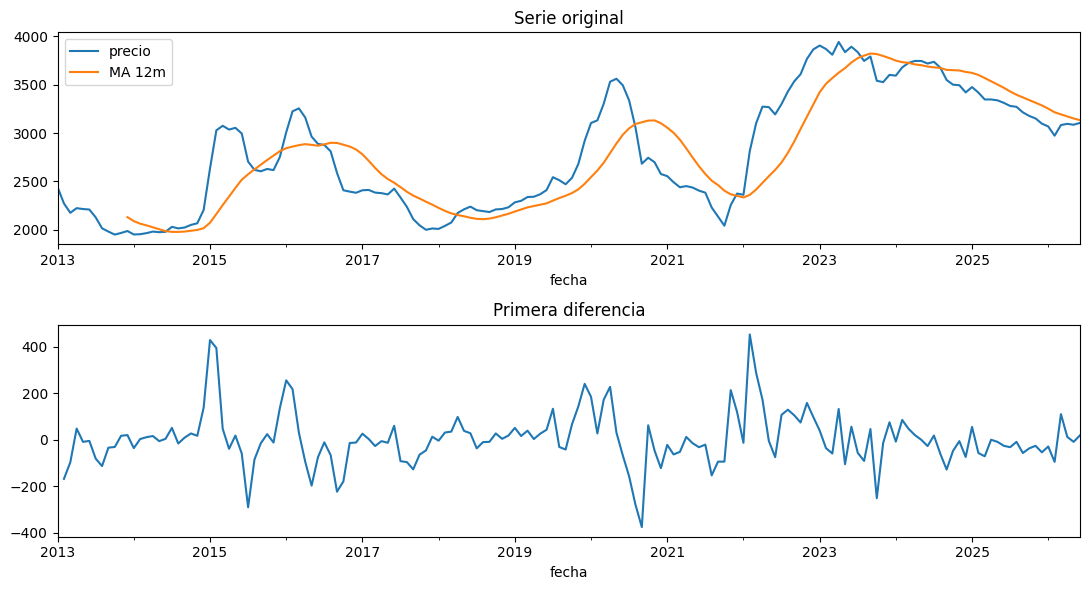

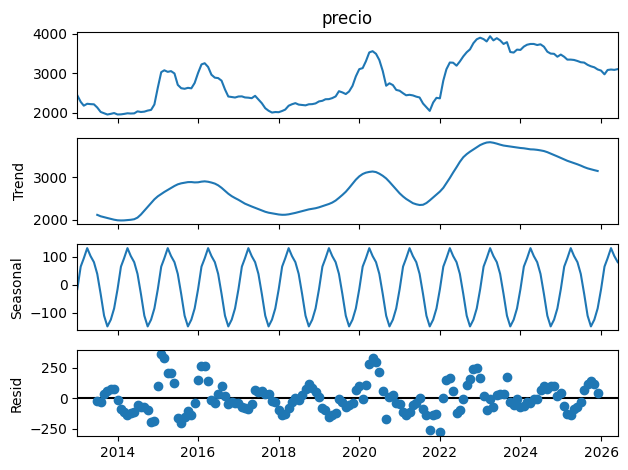

In [50]:
def eda(y):
    fig, ax = plt.subplots(2,1,figsize=(11,6))
    y.plot(ax=ax[0], title="Serie original")
    y.rolling(12).mean().plot(ax=ax[0], label="MA 12m"); ax[0].legend()
    y.diff().plot(ax=ax[1], title="Primera diferencia")
    plt.tight_layout(); plt.show()
    seasonal_decompose(y, model="additive", period=12).plot(); plt.show()
eda(y)

## Fase 3 — Estacionariedad y diferenciación

In [51]:
def test_estacionariedad(x, nombre=''):
    x = x.dropna()
    if len(x) < 8:
        print(f'{nombre}: muestra insuficiente ({len(x)})'); return None, None
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        adf = adfuller(x)[1]
        kps = kpss(x, nlags='auto')[1]
    # p-values de KPSS/ADF estan acotados a la tabla: se reportan como limites
    print(f'{nombre}: ADF p={adf:.3f}{" (<=0.01)" if adf<=0.01 else ""}  '
          f'KPSS p={kps:.3f}{" (limite tabla)" if kps in (0.01, 0.1) else ""}')
    return adf, kps
m = 12
test_estacionariedad(y, 'nivel')
test_estacionariedad(y.diff().dropna(), 'd=1')
if len(y) >= 3*m + 4:
    test_estacionariedad(y.diff().diff(m).dropna(), 'd=1 D=1')
else:
    print(f'd=1 D=1: omitido (serie de {len(y)} < {3*m+4} para diferencia estacional)')

nivel: ADF p=0.197  KPSS p=0.010 (limite tabla)
d=1: ADF p=0.000 (<=0.01)  KPSS p=0.100 (limite tabla)
d=1 D=1: ADF p=0.000 (<=0.01)  KPSS p=0.100 (limite tabla)


## Fase 4 — Identificación (ACF/PACF)

n efectivo tras diferenciar = 149 | lags = 36


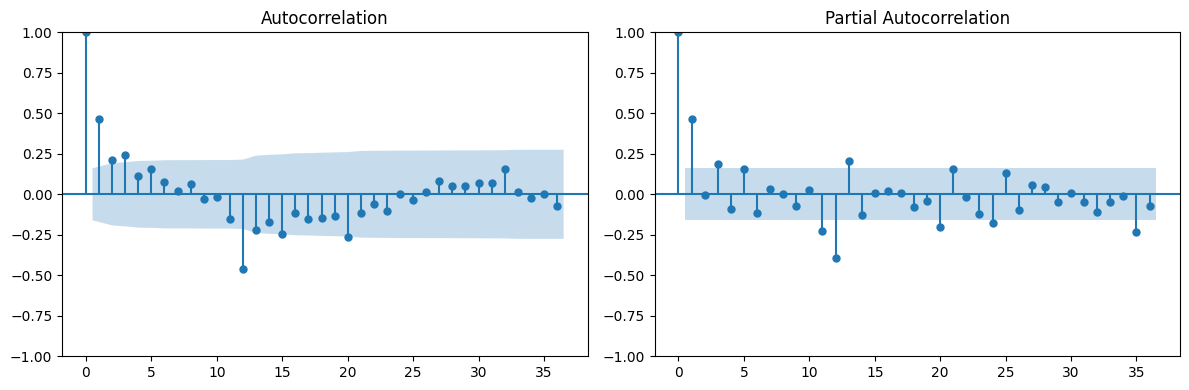

In [52]:
# Fase 4 - ACF/PACF con lags adaptativos (PACF exige lags < n/2)
m = 12
ys = y.dropna()
y_diff = ys.diff().diff(m).dropna() if len(ys) >= 3*m else ys.diff().dropna()
n = len(y_diff)
lags = max(4, min(36, (n // 2) - 1))
print(f'n efectivo tras diferenciar = {n} | lags = {lags}')
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(y_diff, lags=lags, ax=ax[0])
plot_pacf(y_diff, lags=lags, method='ywm', ax=ax[1])
plt.tight_layout(); plt.show()

## Fase 5 — Estimación (auto_arima / grid AIC)

In [53]:
def ajustar_sarima(y, info, m=12, use_log=True):
    """Busca (p,d,q)(P,D,Q,m) respetando el tamaño de la serie."""
    seasonal = info['seasonal_ok']
    y_mod = np.log(y) if use_log else y.copy()
    n = len(y_mod)
    D = 1 if seasonal and n >= 3*m + 4 else 0     # no diferenciar estacional si deja muy pocos datos
    # limites seguros: auto_arima exige max_* >= start_* (start_*=0 aqui)
    max_p = max(1, int(info.get('max_p', 3)))
    max_q = max(1, int(info.get('max_q', 3)))
    max_P = max(0, int(info.get('max_P', 1)))
    max_Q = max(0, int(info.get('max_Q', 1)))
    if not seasonal:
        max_P = max_Q = 0
    if HAS_PMDARIMA:
        model = pm.auto_arima(y_mod, seasonal=seasonal, m=m if seasonal else 1,
                              d=1, D=D,
                              start_p=0, start_q=0, start_P=0, start_Q=0,
                              max_p=max_p, max_q=max_q,
                              max_P=max_P, max_Q=max_Q,
                              stepwise=True, suppress_warnings=True,
                              error_action='ignore', trace=False)
        order, sorder = model.order, model.seasonal_order
    else:
        order  = (min(1, max_p), 1, min(1, max_q))
        sorder = (min(1, max_P), D, min(1, max_Q), m) if seasonal else (0,0,0,0)
    # Guarda: nunca mas parametros que n/8
    k = sum(order[:1]+order[2:3]) + (sorder[0]+sorder[2] if seasonal else 0)
    if k > max(1, n // 8):
        order  = (1,1,0)
        sorder = (1, D, 0, m) if seasonal else (0,0,0,0)
        print('Modelo simplificado por tamaño de muestra.')
    return order, sorder, use_log


In [54]:
order, seasonal_order, use_log = ajustar_sarima(y, info)
print('order=', order, 'seasonal_order=', seasonal_order, 'use_log=', use_log)

order= (2, 1, 1) seasonal_order= (1, 1, 0, 12) use_log= True


## Fase 6 — Diagnóstico de residuos

                                      SARIMAX Results                                      
Dep. Variable:                              precio   No. Observations:                  162
Model:             SARIMAX(2, 1, 1)x(1, 1, [], 12)   Log Likelihood                -252.234
Date:                             Thu, 30 Jul 2026   AIC                            514.469
Time:                                     00:33:07   BIC                            528.995
Sample:                                 01-01-2013   HQIC                           520.372
                                      - 06-01-2026                                         
Covariance Type:                               opg                                         
residuos utiles = 149 | lags diagnostico = 24


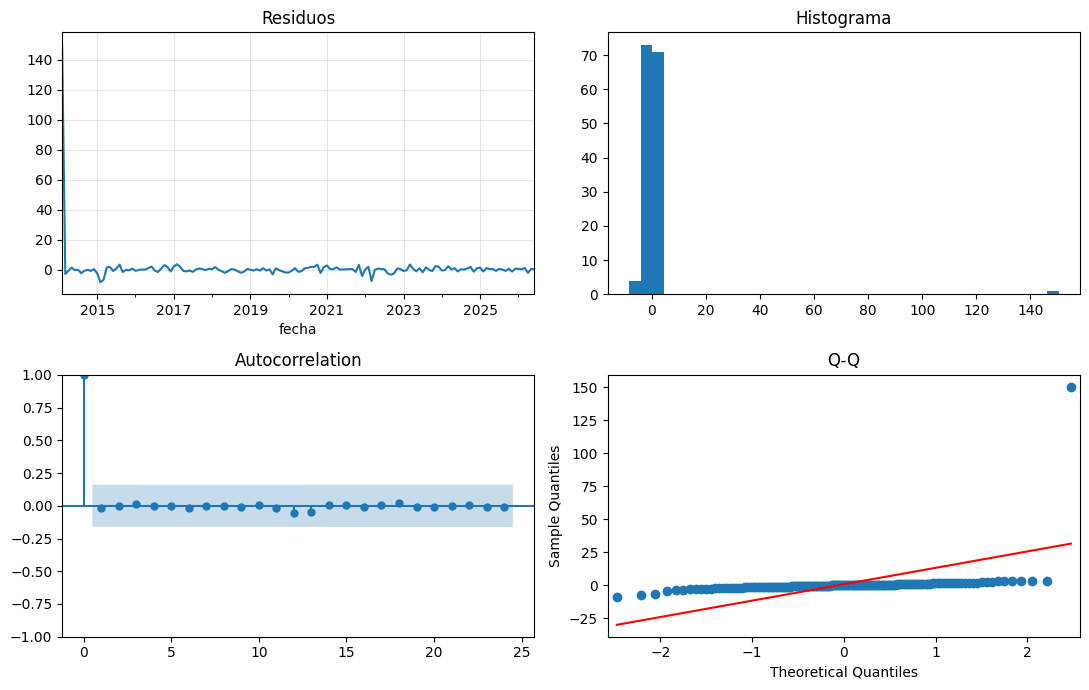

    lb_stat  lb_pvalue
10  0.10685        1.0


In [55]:
# Fase 6 - Diagnostico robusto para series cortas
y_mod = np.log(y) if use_log else y
fit = SARIMAX(y_mod, order=order, seasonal_order=seasonal_order,
              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(fit.summary().tables[0])

resid = pd.Series(fit.resid).replace([np.inf,-np.inf], np.nan).dropna()
# descarta el burn-in inicial del filtro de Kalman
d_burn = order[1] + seasonal_order[1]*(seasonal_order[3] or 0)
resid = resid.iloc[d_burn:]
nr = len(resid)
lags_r = max(2, min(24, (nr // 2) - 1))
print(f'residuos utiles = {nr} | lags diagnostico = {lags_r}')

if nr >= 8:
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    resid.plot(ax=ax[0,0], title='Residuos'); ax[0,0].grid(alpha=.3)
    ax[0,1].hist(resid, bins=max(5, nr//4)); ax[0,1].set_title('Histograma')
    plot_acf(resid, lags=lags_r, ax=ax[1,0])
    qqplot(resid, line='s', ax=ax[1,1]); ax[1,1].set_title('Q-Q')
    plt.tight_layout(); plt.show()
    lb_lags = max(1, min(lags_r, 10))
    print(acorr_ljungbox(resid, lags=[lb_lags], return_df=True))
else:
    print('Muy pocos residuos para diagnostico grafico.')



## Fase 7 — Validación (backtest walk-forward + sMAPE / MASE)

backtest walk-forward: h=12, train inicial=150
MAE    = 20475.014
RMSE   = 65480.545
MAPE   = 660.779
sMAPE  = 62.764
MASE   = 42.409


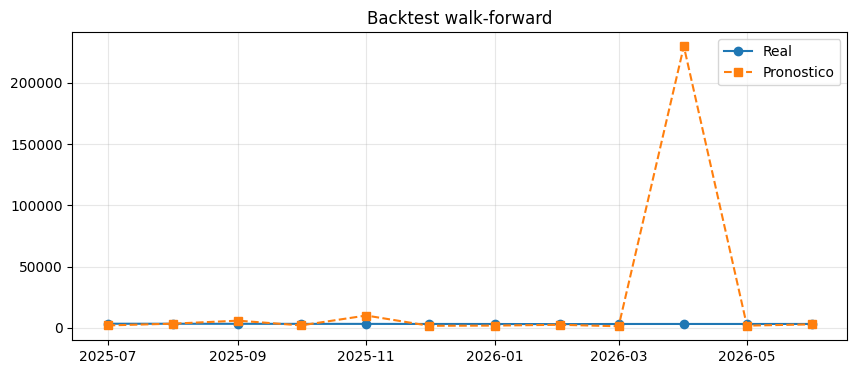

In [56]:
def _metricas(y_true, y_pred, y_train_orig, m=12):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    smape = np.mean(2*np.abs(y_true-y_pred)/(np.abs(y_true)+np.abs(y_pred))) * 100
    yt = np.asarray(y_train_orig, float)
    lag = m if len(yt) > m + 2 else 1        # naive estacional o naive simple
    denom = np.mean(np.abs(yt[lag:] - yt[:-lag])) if len(yt) > lag else np.nan
    mase = mae / denom if denom and denom > 0 else np.nan
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, MASE=mase)

def backtest_wf(y, order, seasonal_order, use_log=True, h=None, m=12, min_train=None):
    n = len(y)
    h = h or int(min(12, max(3, n // 5)))
    min_train = min_train or max(2*m if seasonal_order[3] else 12, 18)
    h = int(min(h, max(1, n - min_train)))   # nunca dejar el train por debajo del minimo
    start = n - h
    preds, reales, idx = [], [], []
    for i in range(h):
        y_train = y.iloc[:start+i]
        ym = np.log(y_train) if use_log else y_train
        try:
            f = SARIMAX(ym, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            fc = f.get_forecast(steps=1)
            p = float(np.exp(fc.predicted_mean.iloc[0])) if use_log else float(fc.predicted_mean.iloc[0])
        except Exception as e:
            print('paso omitido:', e); continue
        preds.append(p); reales.append(float(y.iloc[start+i])); idx.append(y.index[start+i])
    print(f'backtest walk-forward: h={h}, train inicial={start}')
    return _metricas(reales, preds, y.iloc[:start], m=m), reales, preds, idx

metrics, reales, preds, idx = backtest_wf(y, order, seasonal_order,
                                          use_log=use_log, h=info['h_bt'])
for k,v in metrics.items(): print(f'{k:6} = {v:.3f}')

plt.figure(figsize=(10,4))
plt.plot(idx, reales, 'o-', label='Real')
plt.plot(idx, preds, 's--', label='Pronostico')
plt.title('Backtest walk-forward'); plt.legend(); plt.grid(alpha=.3); plt.show()

## Fase 8 — Pronóstico final

In [57]:
def pronosticar(y, order, seasonal_order, use_log=True, steps=1, alpha=0.05):
    ym = np.log(y) if use_log else y
    fit = SARIMAX(ym, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc = fit.get_forecast(steps=steps)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=alpha)
    if use_log:
        # MISMA transformación para punto y límites -> IC coherente y contiene al punto
        mean = np.exp(mean)
        ci   = np.exp(ci)
    return mean, ci, fit

pred, ci, fit_full = pronosticar(y, order, seasonal_order, use_log=use_log, steps=6)
print(pd.concat([pred.rename('pred'), ci], axis=1))


                    pred  lower precio  upper precio
2026-07-01  5.401311e+03  2.522404e+02  1.156602e+05
2026-08-01  1.008339e+13  9.804588e-41  1.037011e+66
2026-09-01           inf  0.000000e+00           inf
2026-10-01           inf  0.000000e+00           inf
2026-11-01           inf  0.000000e+00           inf
2026-12-01           inf  0.000000e+00           inf


## Fase 9 — Persistencia y monitoreo

In [58]:
joblib.dump({'fit':fit_full,'order':order,'seasonal_order':seasonal_order,'use_log':use_log},
            'sarima_model.pkl')
print('modelo guardado')

modelo guardado


## Fase 10: Presentacion de resultados de resultados

In [59]:
m = 12
if len(y) > m:
    naive_next = float(y.iloc[-m])
    print(f'Naive estacional (mismo mes año pasado): {naive_next:,.2f}')
else:
    naive_next = float(y.iloc[-1])
    print(f'Serie corta: se usa naive simple = {naive_next:,.2f}')

mes_obj = (y.index[-1] + pd.offsets.MonthBegin(1)).month
hist = y[y.index.month == mes_obj]
print(f'Historico del mes {mes_obj}: n={len(hist)}  media={hist.mean():,.2f}' if len(hist) else 'Sin historico de ese mes')

Naive estacional (mismo mes año pasado): 3,280.00
Historico del mes 7: n=13  media=2,822.77


##Fase 11: Resumen de serie


In [60]:
def resumen(y, metrics, pred, ci, naive_next):
    ult_mes = y.index[-1].strftime('%Y-%m')
    prox = pred.index[0].strftime('%Y-%m')
    print('='*55)
    print('RESUMEN DE RESULTADOS')
    print('='*55)
    print('Métricas backtest:')
    for k,v in metrics.items(): print(f'  {k:6}= {v:.3f}')
    print('-'*55)
    print(f'Último mes observado ({ult_mes}): {y.iloc[-1]:,.2f}')
    print(f'Promedio últimos 3 meses:        {y.tail(3).mean():,.2f}')
    print(f'Naive estacional (referencia):    {naive_next:,.2f}')
    print(f'Pronóstico SARIMA ({prox}):       {pred.iloc[0]:,.2f}')
    lo, hi = ci.iloc[0,0], ci.iloc[0,1]
    print(f'  Intervalo 95%: [{lo:,.2f} ; {hi:,.2f}]')
    dentro = lo <= pred.iloc[0] <= hi
    print(f'  Punto dentro del IC: {dentro}  {"✓" if dentro else "✗ REVISAR"}')
    var = (pred.iloc[0]/y.iloc[-1]-1)*100
    print(f'  Variación vs último mes: {var:+.1f}%')
    print('='*55)

resumen(y, metrics, pred, ci, naive_next)


RESUMEN DE RESULTADOS
Métricas backtest:
  MAE   = 20475.014
  RMSE  = 65480.545
  MAPE  = 660.779
  sMAPE = 62.764
  MASE  = 42.409
-------------------------------------------------------
Último mes observado (2026-06): 3,105.00
Promedio últimos 3 meses:        3,095.33
Naive estacional (referencia):    3,280.00
Pronóstico SARIMA (2026-07):       5,401.31
  Intervalo 95%: [252.24 ; 115,660.15]
  Punto dentro del IC: True  ✓
  Variación vs último mes: +74.0%


**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
